In [5]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt
import dgl
from math import ceil
from tqdm import tqdm
import torch
import networkx as nx
import datetime
k = 4
graph = dgl.load_graphs('static/Enrollments_4_25_True/graph')[0][0]
max_len = 0
for u in torch.arange(0, graph.num_nodes('item')):
    max_len = max(max_len, len(graph.successors(u, etype='by')))
print(max_len)

# users, items, eid = graph.edges('all', etype='pby')
# last_user = users.max()
# items += last_user + 1
# last_item = items.max()
# eid += last_item + 1
# edata = torch.stack([users, items, eid], -1)
# edata = torch.cat([edata[:, ::2], edata[:, :2]])
# edata = torch.cat([torch.flip(edata, (-1,)), edata])
# edata = [tuple(pair) for pair in edata]
# graph = nx.Graph(edata)

# graph = dgl.graph((torch.cat([users, items]), torch.cat([items, users])))
# num_nodes = [[] for khop in range(k + 1)]
# num_users = [[] for khop in range(k + 1)]
# num_items = [[] for khop in range(k + 1)]
# num_edges = [[] for khop in range(k + 1)]
# for khop in range(k + 1):
# 	for node in tqdm(graph.nodes()):
# 		if node.item() <= last_user:
# 			subgraph, _ = dgl.khop_out_subgraph(graph, node.item(), khop)
# 			num_nodes[khop].append(subgraph.num_nodes())
# 			num_users[khop].append((subgraph.ndata[dgl.NID] <= last_user).sum().item())
# 			num_items[khop].append((subgraph.ndata[dgl.NID] > last_user).sum().item())
# 			num_edges[khop].append(subgraph.num_edges())

DGLError: File static/Enrollments_4_25_True/graph does not exist.

In [4]:
pairs = nx.all_pairs_shortest_path_length(graph)

In [33]:
p = next(pairs)
while len(p[1]) == 2 and list(p[1].values()) == [0, 1]:
    p = next(pairs)
print(p[1])

In [2]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt
import dgl
from math import ceil
from tqdm import tqdm
import torch
import networkx as nx
k = 4
graph = dgl.load_graphs('enrollment_graph')[0][0]
users, items, eid = graph.edges('all', etype='pby')
last_user = users.max()
items += last_user + 1
last_item = items.max()
eid += last_item + 1
edata = torch.stack([users, items, eid], -1)
edata = [[eid, users], [eid, items], [users, eid], [items, eid]]
edata = torch.cat([torch.stack(x, -1) for x in edata], 0)
edata = [tuple(pair) for pair in edata]
print(edata)
graph = nx.Graph(edata)
print(nx.all_pairs_shortest_path_length(graph))

torch.Size([2387605, 3])


AttributeError: 'list' object has no attribute 'shape'

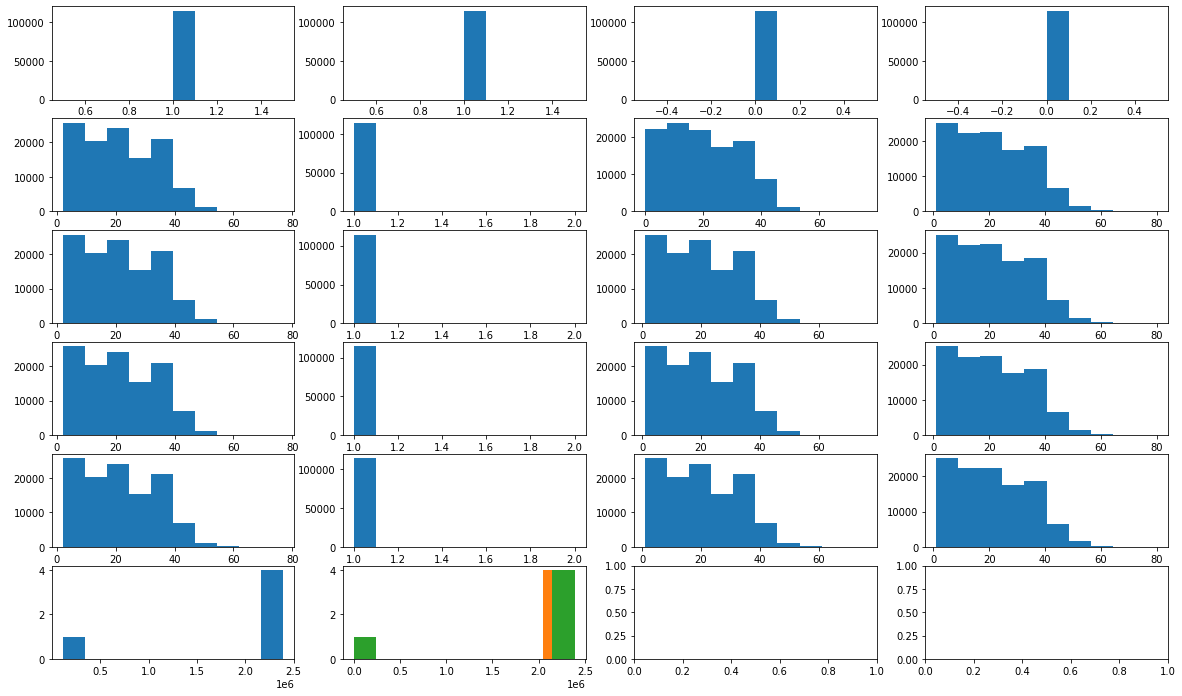

In [ ]:
fig, ax = plt.subplots(k + 2, 4, figsize=(20, 12))
for khop in range(k + 1):
    ax[khop][0].hist(num_nodes[khop])
    ax[khop][1].hist(num_users[khop])
    ax[khop][2].hist(num_items[khop])
    ax[khop][3].hist(num_edges[khop])
ax[k + 1][0].hist([sum(nodes) for nodes in num_nodes])
ax[k + 1][1].hist([sum(users) for users in num_users])
ax[k + 1][1].hist([sum(items) for items in num_items])
ax[k + 1][1].hist([sum(edges) for edges in num_edges])
plt.show()

In [6]:
import torch
import pickle
from DGSR import DGSR
from utils import get_collate, StaticData
from torch.utils.data import DataLoader
from torch import optim, nn

load = 'static/Enrollments_4_25/bs50_lr0.001_ep30_l20.0001_ft0.0_at0.0_ln3_hs50_mu25_mi5_k3_bce.out'
margin = False
feat_drop = 0.0
attn_drop = 0.0
gpu = 2
epoch = 1

device = torch.device(f'cuda:{gpu}')
torch.cuda.set_device(device)
print(f"device: {device}")
#print(f"opt: {opt}")

data_path = 'static/Enrollments_4_25/'
metadata_path = 'static/Enrollments_4_25/meta'
test_path = 'static/Enrollments_4_25/test/'
neg_path = 'static/Enrollments_4_25/neg'

with open(metadata_path, 'rb') as file:
    metadata = pickle.load(file)
    user_num = metadata['user_num']
    item_num = metadata['item_num']
    etypes = metadata['etypes']

with open(neg_path, 'rb') as f:
    data_neg = pickle.load(f) # negatives for evaluation
    
test_set = StaticData(test_path)
collate_test = get_collate(item_num, 25, 5, 3, False, data_neg)
test_data = DataLoader(dataset=test_set, batch_size=50, collate_fn=collate_test, shuffle=True, pin_memory=True, num_workers=12)

# initialize the model
model = DGSR(etypes=etypes, user_num=user_num, item_num=item_num, input_dim=50, max_lookback=25, 
             feat_drop=feat_drop, attn_drop=attn_drop, layer_num=3).cuda()

state = torch.load(load)
model.load_state_dict(state)
#optimizer = optim.Adam(model.parameters(), lr=opt.lr, weight_decay=opt.l2)
Loss = nn.MultiLabelMarginLoss if margin else nn.BCEWithLogitsLoss
loss_func = Loss(reduction='mean').to(device)
best = {}
stop_num = 0
epoch_start = None

for epoch in range(epoch):
	stop = True
	epoch_loss = 0
	val_loss = 0
	test_loss = 0
	iter = 0
		
	############################ test ############################
	print('start testing: ', datetime.datetime.now())
	ranks, neg_idxs = [], []
	iter = 0
	with torch.no_grad():
		for batch_graph, user, target, all_label, num_pos in test_data:
			iter += 1
			batch_graph = batch_graph.to(device)
			user = user.cuda()
			target = target.cuda()
			all_label = all_label.cuda()
			num_pos = num_pos.cuda()
			score, all_score = model(batch_graph, user, all_label=all_label, is_training=False)
			if margin:
				score = torch.sigmoid(score)
			loss = loss_func(score, target)
			test_loss += loss.cpu().item()
			perm = torch.randperm(all_score.shape[-1])
			all_score = -all_score[..., perm]
			rank = all_score.argsort(-1).argsort(-1)
			rank = rank[..., torch.argsort(perm)]
			ranks.append(rank)
			neg_idxs.append(num_pos)
			if iter % 200 == 0:
				if not opt.nosave:
					all_score = all_score[..., torch.argsort(perm)]
					#torch.save(score, results_path + f"test_score_{epoch}_{iter}")
					#torch.save(rank, results_path + f"test_rank_{epoch}_{iter}")
					#torch.save(all_score, results_path + f"test_all_score_{epoch}_{iter}")
				print('\tIter {}, test_loss {:.4f}'.format(iter, test_loss / iter), datetime.datetime.now(), flush=True)
			del user, target, score, loss, all_label, perm, all_score
			torch.cuda.empty_cache()
		ranks = torch.cat(ranks, 0)
		neg_idxs = torch.cat(neg_idxs, 0)
		results = eval_metric(ranks, neg_idxs, device)
	for metric_name, val in results.items():
		if metric_name not in best or val > best[metric_name][0]:
			stop = metric_name not in best   # stop=False when val exceeds best_result
			best[metric_name] = (val, epoch)
		if epoch == best[metric_name][1] and not opt.nosave:
			file_add = '' if metric_name == 'recall@10' else f'_{metric_name}'
			#torch.save(model.state_dict(), model_file + file_add)
	if stop:
		stop_num += 1
	else:
		stop_num = 0
	results_str = '\n'.join([f"{metric_name}: {val:.4f}" for metric_name, val in results.items()])
	print(f"train_loss:{epoch_loss:.4f} \
			\ntest_loss:{test_loss / iter:.4f} \
			\n{results_str}", flush=True)
	print('Epoch {}'.format(epoch + 1), '=============================================')

start testing:  2022-08-01 17:03:06.867149


NameError: name 'device' is not defined

(array([[22.,  0.,  0., ...,  0.,  0.,  3.],
        [22.,  0.,  0., ...,  0.,  0.,  3.],
        [22.,  0.,  0., ...,  0.,  0.,  3.],
        ...,
        [22.,  0.,  0., ...,  0.,  0.,  3.],
        [22.,  0.,  0., ...,  0.,  0.,  3.],
        [22.,  0.,  0., ...,  0.,  0.,  3.]]),
 array([4.7992240e-04, 5.0431930e-02, 1.0038394e-01, 1.5033595e-01,
        2.0028795e-01, 2.5023997e-01, 3.0019197e-01, 3.5014397e-01,
        4.0009600e-01, 4.5004800e-01, 5.0000000e-01], dtype=float32),
 <a list of 4925 BarContainer objects>)

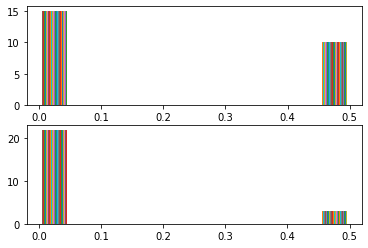

In [4]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import torch
pos_weights = [0.5, 1.0, 2.0]
dir = "static/Enrollments_4_25_False/bs25_lr0.001_ep30_l20.0001_pw1.0_ft0.0_at0.2_ln3_hs50_mu25_mi25_k3_bce/"

fig, ax = plt.subplots(2)
score = torch.load(dir + 'score_0_1000')
all_score = torch.load(dir + 'test_score_0_1000')
ax[0].hist(torch.sigmoid(score).detach().cpu().numpy())
ax[1].hist(torch.sigmoid(all_score).detach().cpu().numpy())

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('data/Enrollments.csv')
print(data['time'].max())

23


In [2]:
new_items = np.setdiff1d(data[data['time'] > 19]['item_id'].values, data[data['time'] < 20]['item_id'].values)
print(f'there are {len(new_items)} courses in the last 4 semesters not in the previous 19')
new_data = data[data['time'] > 19]
new_str = f"there were {len(new_data)} enrollment records in {len(new_data['item_id'].unique())} unique courses in the last 4 semesters "
new_str += f"among {len(new_data['user_id'].unique())} students, for an average of "
new_str += f"{len(new_data) / len(new_data['user_id'].unique()):2f} courses per student over all 4 semesters"
print(new_str)
only_new = new_data[new_data['item_id'].isin(new_items)]
only_new_str = f"among the {len(new_items)} new courses in the last 4 semesters, there were "
only_new_str += f"{len(only_new)} enrollment records among {len(only_new['user_id'].unique())} " 
all_item = new_data[new_data['user_id'].isin(only_new['user_id'].unique())]
only_new_str += f"users who enrolled in {len(all_item)} courses, for an average of "
only_new_str += f"{len(all_item) / len(only_new['user_id'].unique())} courses per student over all 4 semesters. "
only_new_str += f"These enrollment records are {100 * len(only_new) / len(new_data):2f}% of all enrollments "
only_new_str += f"and {100 * len(only_new) / len(all_item):2f}% of the enrollments of the users who took a new course."
print(only_new_str)

there are 241 courses in the last 4 semesters not in the previous 19
there were 388197 enrollment records in 3284 unique courses in the last 4 semesters among 40266 students, for an average of 9.640814 courses per student over all 4 semesters
among the 241 new courses in the last 4 semesters, there were 17939 enrollment records among 10621 users who enrolled in 122146 courses, for an average of 11.50042368891818 courses per student over all 4 semesters. These enrollment records are 4.621107% of all enrollments and 14.686523% of the enrollments of the users who took a new course.
